# Confusion Matrix, Sensitivity & Specificity

**Goal:** Predict heart disease and learn how to read a *confusion matrix*, then compare two models (**Random Forest** vs **KNN**) using **sensitivity** and **specificity**.

## The four outcomes

For a binary classifier, every prediction falls into one of four buckets. Here the **positive** class = *heart disease present (1)*.

| | Predicted: No disease (0) | Predicted: Disease (1) |
|---|---|---|
| **Actual: No disease (0)** | True Negative (TN) | False Positive (FP) |
| **Actual: Disease (1)**    | False Negative (FN) | True Positive (TP) |

## The two metrics we compare

$$\text{Sensitivity (Recall, TPR)} = \frac{TP}{TP + FN}$$

> Of all the patients who **actually have** the disease, what fraction did we catch? A *false negative* (missing a sick patient) is dangerous in medicine, so we usually want sensitivity to be high.

$$\text{Specificity (TNR)} = \frac{TN}{TN + FP}$$

> Of all the patients who are **actually healthy**, what fraction did we correctly clear? A *false positive* means alarming a healthy person and ordering unnecessary tests.

In [1]:
import numpy as np
import pandas as pd
import os
import kagglehub
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

## 1. Load the data

We pull the **Heart Failure Prediction** dataset from Kaggle (`fedesoriano/heart-failure-prediction`, one of the most-upvoted heart datasets) using `kagglehub`. It has 918 patients, 11 clinical features, and target `HeartDisease` (1 = disease present, 0 = absent). `kagglehub` downloads the dataset once and caches it locally (`~/.cache/kagglehub`), so re-runs are instant.

A few columns are **categorical** (e.g. `Sex`, `ChestPainType`, `ST_Slope`), so we one-hot encode them before training.

In [2]:
# Downloads (and caches) the dataset, returns the local folder path.
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
df = pd.read_csv(os.path.join(path, "heart.csv"))

print("Shape:", df.shape)
print("\nClass balance (1 = disease present):")
print(df["HeartDisease"].value_counts())
df.head()

Shape: (918, 12)

Class balance (1 = disease present):
HeartDisease
1    508
0    410
Name: count, dtype: int64


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
# One-hot encode the categorical columns (Sex, ChestPainType, RestingECG,
# ExerciseAngina, ST_Slope). drop_first avoids redundant columns.
X = pd.get_dummies(df.drop(columns="HeartDisease"), drop_first=True)
y = df["HeartDisease"]

print("Features after encoding:", X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y,          # keep the same disease ratio in train and test
)

# KNN is distance-based, so it needs features on the same scale.
# Fit the scaler on train only, then apply to test (no leakage).
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Features after encoding: 15
Train size: 688 | Test size: 230


## 2. Train the two models

- **Random Forest** is tree-based and scale-invariant, so it uses the raw features.
- **KNN** uses Euclidean distance, so it uses the *scaled* features.

In [4]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print(f"Random Forest accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"KNN accuracy:           {accuracy_score(y_test, y_pred_knn):.3f}")

Random Forest accuracy: 0.883
KNN accuracy:           0.896


## 3. Confusion matrices

`confusion_matrix` returns the layout below (rows = actual, cols = predicted), with `labels=[0, 1]`:

```
          pred 0   pred 1
actual 0   [ TN      FP ]
actual 1   [ FN      TP ]
```

Random Forest confusion matrix:
 [[ 87  16]
 [ 11 116]]

KNN confusion matrix:
 [[ 90  13]
 [ 11 116]]


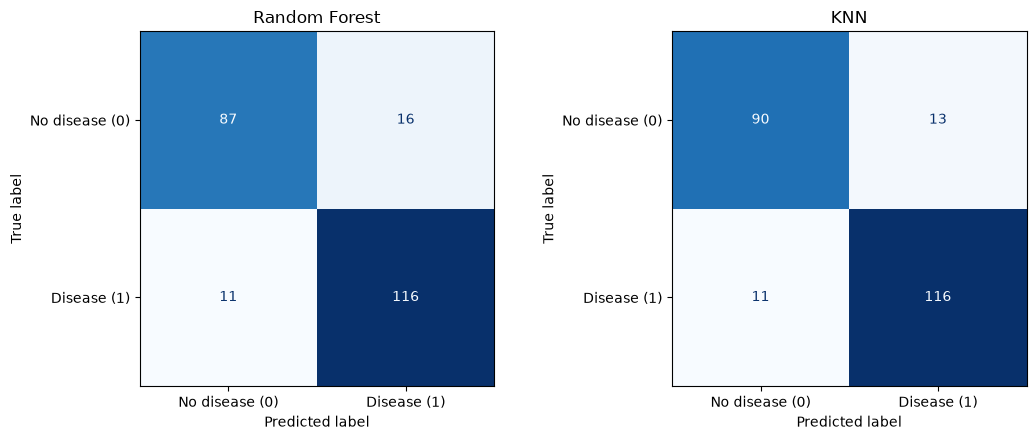

In [5]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=[0, 1])

print("Random Forest confusion matrix:\n", cm_rf)
print("\nKNN confusion matrix:\n", cm_knn)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
display_labels = ["No disease (0)", "Disease (1)"]

for ax, cm, title in zip(axes, [cm_rf, cm_knn], ["Random Forest", "KNN"]):
    ConfusionMatrixDisplay(cm, display_labels=display_labels).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 4. Sensitivity & specificity from the matrix

We unpack the four cells and apply the formulas by hand so the link between the matrix and the metrics is explicit.

In [6]:
def sens_spec(cm):
    """cm laid out as [[TN, FP], [FN, TP]] with labels=[0, 1]."""
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)   # recall on the positive (disease) class
    specificity = tn / (tn + fp)   # recall on the negative (healthy) class
    return tn, fp, fn, tp, sensitivity, specificity

rows = []
for name, cm in [("Random Forest", cm_rf), ("KNN", cm_knn)]:
    tn, fp, fn, tp, sens, spec = sens_spec(cm)
    rows.append({
        "model": name,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "sensitivity": round(sens, 3),
        "specificity": round(spec, 3),
    })

results = pd.DataFrame(rows).set_index("model")
results

,TN,FP,FN,TP,sensitivity,specificity
model,,,,,,
Random Forest,87,16,11,116,0.913,0.845
KNN,90,13,11,116,0.913,0.874


## 5. Compare

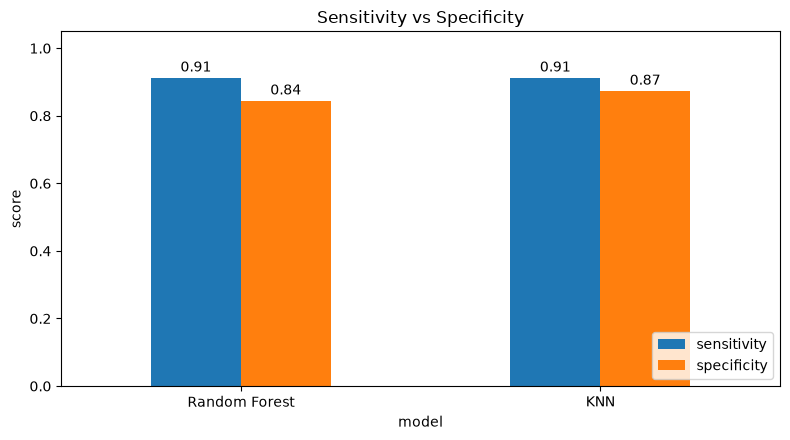

In [7]:
ax = results[["sensitivity", "specificity"]].plot(
    kind="bar", figsize=(8, 4.5), rot=0, ylim=(0, 1.05)
)
ax.set_title("Sensitivity vs Specificity")
ax.set_ylabel("score")
ax.legend(loc="lower right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=2)
plt.tight_layout()
plt.show()